# 1. Importação de bibliotecas


In [16]:
import zipfile
import os
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.ensemble import RandomForestRegressor

# 2. Download e carregamento dos dados

In [17]:
files.upload() #kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ashyou09/global-data-center-and-ai-waterelectricity-usage

zip_name = "global-data-center-and-ai-waterelectricity-usage.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_path)

print("Arquivos extraídos:")
for f in os.listdir(extract_path):
    print(f)

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/ashyou09/global-data-center-and-ai-waterelectricity-usage
License(s): apache-2.0
global-data-center-and-ai-waterelectricity-usage.zip: Skipping, found more recently modified local copy (use --force to force download)
Arquivos extraídos:
data_center_hybrid.csv


# 3. Análise exploratória

In [18]:
df = pd.read_csv("/content/dataset/data_center_hybrid.csv")

print(df.shape)

(126770, 14)


In [19]:
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [20]:
df.columns

Index(['Year', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City',
       'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
       'Daily_Water_Usage_Gallons', 'Surrounding_Water_Stress_Tier'],
      dtype='object')

## 3.1. Remoção de colunas irrelevantes

In [21]:
X = df.drop(['Daily_Water_Usage_Gallons', 'Facility_ID', 'Facility_Name', 'Owner_Company', 'City'], axis=1)

y = df['Daily_Water_Usage_Gallons']

In [22]:
X.columns

Index(['Year', 'Country', 'Facility_Type', 'Estimated_Capacity_MW', 'PUE',
       'Cooling_System_Type', 'WUE_L_per_kWh', 'Daily_Electricity_Usage_MWh',
       'Surrounding_Water_Stress_Tier'],
      dtype='object')

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Country                        126770 non-null  object 
 2   Facility_Type                  126770 non-null  object 
 3   Estimated_Capacity_MW          126770 non-null  float64
 4   PUE                            126770 non-null  float64
 5   Cooling_System_Type            126770 non-null  object 
 6   WUE_L_per_kWh                  126770 non-null  float64
 7   Daily_Electricity_Usage_MWh    126770 non-null  float64
 8   Surrounding_Water_Stress_Tier  126770 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 8.7+ MB


In [24]:
X.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000
mean,2022.000000,23.075117,1.637746,0.820596,605.222368
std,2.000008,45.847195,0.190833,0.925481,1040.061940
min,2019.000000,1.000000,1.057000,0.001000,22.190000
25%,2020.000000,5.450000,1.518000,0.139000,167.432500
50%,2022.000000,9.870000,1.643000,0.232000,302.750000
75%,2024.000000,14.180000,1.787000,1.654000,451.370000
max,2025.000000,562.890000,2.000000,3.000000,14812.660000


In [25]:
X.isnull().sum()

,0
Year,0
Country,0
Facility_Type,0
Estimated_Capacity_MW,0
PUE,0
Cooling_System_Type,0
WUE_L_per_kWh,0
Daily_Electricity_Usage_MWh,0
Surrounding_Water_Stress_Tier,0


# 4. Pré-processamento


In [26]:
#machine learning não aceita texto diretamente
X = pd.get_dummies(X, columns=['Facility_Type', 'Cooling_System_Type', 'Country', 'Surrounding_Water_Stress_Tier'])

# 5. Execução com 30 sementes diferentes

## 5.1. Regressão Linear — 30 sementes

In [27]:
sementes = list(range(30))
n_estimators_fixo = 100

resultados_lr = []

for seed in sementes:
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=seed)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=seed)

    modelo_lr = LinearRegression()

    inicio_treino_lr = time.time()
    modelo_lr.fit(X_train, y_train)
    fim_treino_lr = time.time()
    tempo_treino_lr = fim_treino_lr - inicio_treino_lr

    inicio_predicao_lr = time.time()
    y_pred_val_lr = modelo_lr.predict(X_val)
    fim_predicao_lr = time.time()
    tempo_pred_lr = fim_predicao_lr - inicio_predicao_lr

    mae_lr = mean_absolute_error(y_val, y_pred_val_lr)
    rmse_lr = mean_squared_error(y_val, y_pred_val_lr) ** 0.5
    r2_lr = r2_score(y_val, y_pred_val_lr)

    resultados_lr.append({'seed': seed, 'mae': mae_lr, 'rmse': rmse_lr, 'r2': r2_lr, 'tempo_treino': tempo_treino_lr, 'tempo_predicao': tempo_pred_lr})

df_lr = pd.DataFrame(resultados_lr)

print("REGRESSÃO LINEAR (resultados por semente)")
print(df_lr.to_string(index=False))

print("\nREGRESSÃO LINEAR (estatísticas)")
print(df_lr[['mae', 'rmse', 'r2', 'tempo_treino', 'tempo_predicao']].agg(['mean', 'std', 'min', 'max']))

REGRESSÃO LINEAR (resultados por semente)
 seed          mae          rmse       r2  tempo_treino  tempo_predicao
    0 92605.248544 202019.578027 0.717648      3.099367        0.071471
    1 90292.420711 196943.815489 0.753447      3.015510        0.050000
    2 92888.620625 202437.765450 0.748755      5.518362        0.057816
    3 94234.620288 206839.489255 0.744872      3.072047        0.044985
    4 92216.878755 204262.463055 0.751695      3.018454        0.045045
    5 90174.919005 196172.313943 0.737472      5.082735        0.045522
    6 91228.498355 199384.221445 0.740827      2.997079        0.052681
    7 92641.079781 207299.228386 0.734368      2.987961        0.045971
    8 93099.016084 211243.058666 0.734889      2.981093        0.087284
    9 92567.469573 203585.160632 0.747723      4.548207        0.044916
   10 92122.249151 203340.002934 0.738511      2.970245        0.043607
   11 91140.812509 199629.042126 0.742042      3.013528        0.044752
   12 92113.685955 201

### 5.1.1. Gráfico — R² da Regressão Linear por semente


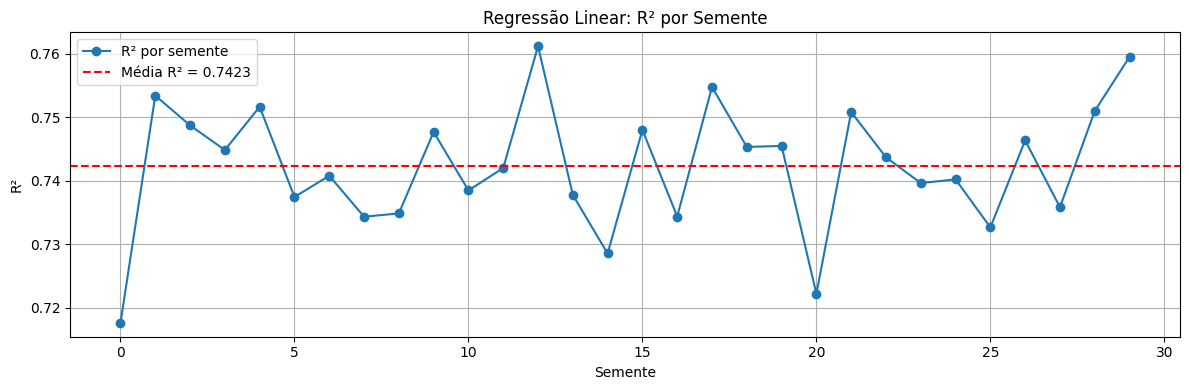

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(df_lr['seed'], df_lr['r2'], marker='o', label='R² por semente')
plt.axhline(df_lr['r2'].mean(), color='red', linestyle='--', label=f"Média R² = {df_lr['r2'].mean():.4f}")
plt.xlabel("Semente")
plt.ylabel("R²")
plt.title("Regressão Linear: R² por Semente")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.1.2. Gráfico — Real vs Previsto (última semente)



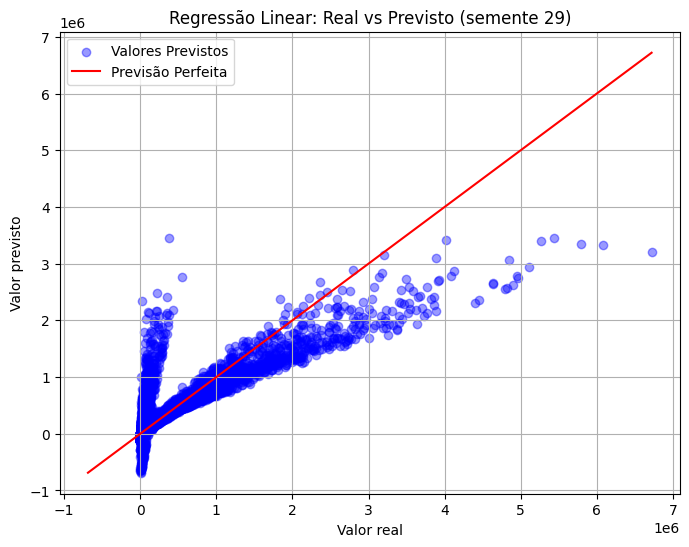

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_val_lr, alpha=0.4, color='blue', label='Valores Previstos')
min_val = min(y_val.min(), y_pred_val_lr.min())
max_val = max(y_val.max(), y_pred_val_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Previsão Perfeita')
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(f"Regressão Linear: Real vs Previsto (semente {sementes[-1]})")
plt.legend()
plt.grid(True)
plt.show()

## 5.2. Random Forest — 30 sementes



In [30]:
resultados_rf = []

for seed in sementes:
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=seed)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=seed)

    modelo_rf = RandomForestRegressor(n_estimators=n_estimators_fixo, random_state=seed)

    inicio_treino_rf = time.time()
    modelo_rf.fit(X_train, y_train)
    fim_treino_rf = time.time()
    tempo_treino_rf = fim_treino_rf - inicio_treino_rf

    inicio_predicao_rf = time.time()
    y_pred_val_rf = modelo_rf.predict(X_val)
    fim_predicao_rf = time.time()
    tempo_pred_rf = fim_predicao_rf - inicio_predicao_rf

    mae_rf = mean_absolute_error(y_val, y_pred_val_rf)
    rmse_rf = mean_squared_error(y_val, y_pred_val_rf) ** 0.5
    r2_rf = r2_score(y_val, y_pred_val_rf)

    resultados_rf.append({'seed': seed, 'n_estimators': n_estimators_fixo, 'mae': mae_rf, 'rmse': rmse_rf, 'r2': r2_rf, 'tempo_treino': tempo_treino_rf, 'tempo_predicao': tempo_pred_rf})

df_rf = pd.DataFrame(resultados_rf)

print("RANDOM FOREST (resultados por semente)")
print(df_rf.to_string(index=False))

print("\nRANDOM FOREST (estatísticas)")
print(df_rf[['mae', 'rmse', 'r2', 'tempo_treino', 'tempo_predicao']].agg(['mean', 'std', 'min', 'max']))

RANDOM FOREST (resultados por semente)
 seed  n_estimators         mae         rmse       r2  tempo_treino  tempo_predicao
    0           100 2474.327998 12400.303252 0.998936    216.511875        1.034267
    1           100 2591.567775 15191.845648 0.998533    223.902732        1.001360
    2           100 2665.235671 15324.303147 0.998560    218.649015        0.964361
    3           100 2611.636973 14139.085492 0.998808    213.418793        0.953649
    4           100 2544.937443 12943.388534 0.999003    214.963886        0.939612
    5           100 2658.384724 17972.258396 0.997797    213.835541        0.959985
    6           100 2563.719083 14437.206257 0.998641    213.477961        0.957349
    7           100 2548.113746 14818.690322 0.998643    212.178082        0.951060
    8           100 2596.238239 13432.633799 0.998928    211.997471        0.952532
    9           100 2670.665145 14007.813846 0.998806    220.700066        0.993915
   10           100 2648.836944 14322

### 5.2.1. Gráfico — R² do Random Forest por semente


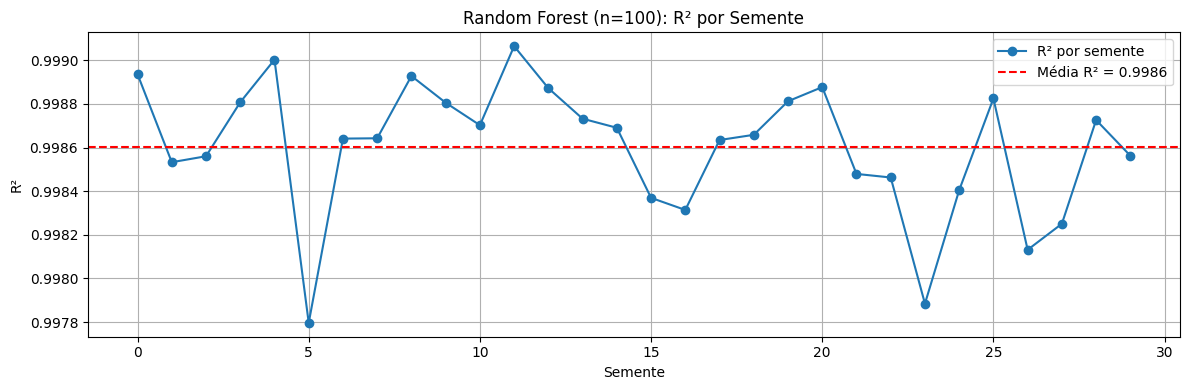

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(df_rf['seed'], df_rf['r2'], marker='o', label='R² por semente')
plt.axhline(df_rf['r2'].mean(), color='red', linestyle='--', label=f"Média R² = {df_rf['r2'].mean():.4f}")
plt.xlabel("Semente")
plt.ylabel("R²")
plt.title(f"Random Forest (n={n_estimators_fixo}): R² por Semente")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5.2.2. Gráfico — Real vs Previsto (última semente)



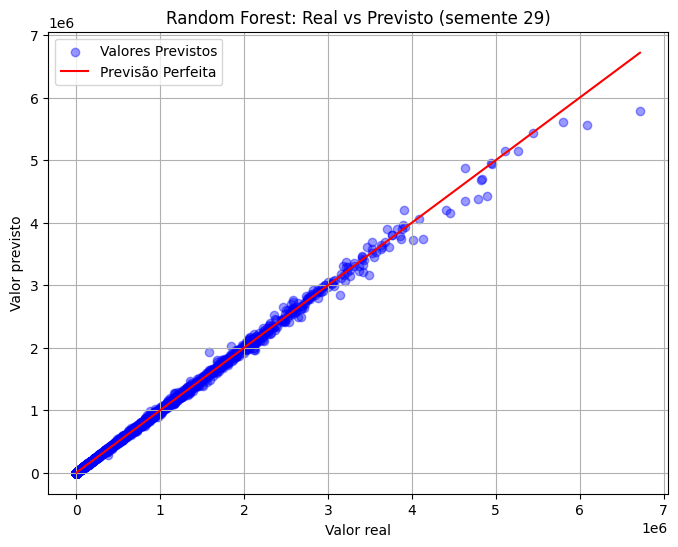

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred_val_rf, alpha=0.4, color='blue', label='Valores Previstos')
min_val = min(y_val.min(), y_pred_val_rf.min())
max_val = max(y_val.max(), y_pred_val_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Previsão Perfeita')
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(f"Random Forest: Real vs Previsto (semente {sementes[-1]})")
plt.legend()
plt.grid(True)
plt.show()


### 5.2.3. Importância de variáveis (última semente)

                                 Variavel  Importancia
1                   Estimated_Capacity_MW     0.456399
3                           WUE_L_per_kWh     0.298404
4             Daily_Electricity_Usage_MWh     0.229850
9         Cooling_System_Type_Evaporative     0.012008
2                                     PUE     0.002820
7             Facility_Type_Hyperscale/AI     0.000108
0                                    Year     0.000102
5                Facility_Type_Colocation     0.000089
357  Surrounding_Water_Stress_Tier_Medium     0.000042
355    Surrounding_Water_Stress_Tier_High     0.000038


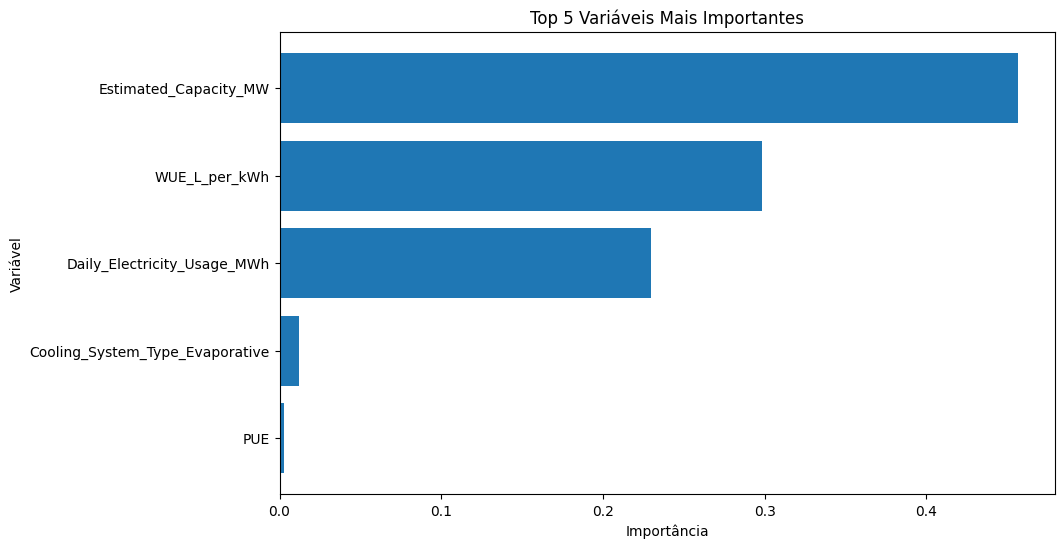

In [33]:
importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Variavel': X.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

print(df_importancias.head(10))

top5 = df_importancias.head(5)
plt.figure(figsize=(10, 6))
plt.barh(top5['Variavel'], top5['Importancia'])
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('Top 5 Variáveis Mais Importantes')
plt.gca().invert_yaxis()
plt.show()

## 5.3. Variação do n_estimators do Random Forest (última semente)

In [34]:
seed_final = sementes[-1]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=seed_final)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1765, random_state=seed_final)

resultados_n = []

for n in [10, 50, 100, 150]:
    modelo_rf_n = RandomForestRegressor(n_estimators=n, random_state=seed_final)

    inicio_treino_rf = time.time()
    modelo_rf_n.fit(X_train, y_train)
    fim_treino_rf = time.time()
    tempo_treino_rf = fim_treino_rf - inicio_treino_rf

    inicio_predicao_rf = time.time()
    y_pred_n = modelo_rf_n.predict(X_val)
    fim_predicao_rf = time.time()
    tempo_pred_rf = fim_predicao_rf - inicio_predicao_rf

    resultados_n.append([n, tempo_treino_rf, tempo_pred_rf, mean_absolute_error(y_val, y_pred_n), mean_squared_error(y_val, y_pred_n) ** 0.5, r2_score(y_val, y_pred_n)])

df_n = pd.DataFrame(resultados_n, columns=['n_estimators', 'tempo_treino', 'tempo_pred', 'mae_rf', 'rmse_rf', 'r2_rf'])
print(df_n)

   n_estimators  tempo_treino  tempo_pred       mae_rf       rmse_rf     r2_rf
0            10     21.985017    0.108189  3201.521985  16807.847779  0.998261
1            50    107.502854    0.519465  2711.231053  15614.635686  0.998499
2           100    218.074473    1.157356  2624.280257  15280.109031  0.998563
3           150    325.310059    1.584441  2616.019395  15346.116024  0.998550


# 6. Comparação entre LR e RF (média das 30 sementes)

In [35]:
comparacao = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'Random Forest'],
    'MAE (média)': [df_lr['mae'].mean(), df_rf['mae'].mean()],
    'MAE (std)': [df_lr['mae'].std(), df_rf['mae'].std()],
    'RMSE (média)': [df_lr['rmse'].mean(), df_rf['rmse'].mean()],
    'RMSE (std)': [df_lr['rmse'].std(), df_rf['rmse'].std()],
    'R² (média)': [df_lr['r2'].mean(), df_rf['r2'].mean()],
    'R² (std)': [df_lr['r2'].std(), df_rf['r2'].std()],
    'Tempo treino (média s)': [df_lr['tempo_treino'].mean(), df_rf['tempo_treino'].mean()],
    'Tempo pred (média s)': [df_lr['tempo_predicao'].mean(),df_rf['tempo_predicao'].mean()]})

print(comparacao.to_string(index=False))

          Modelo  MAE (média)   MAE (std)  RMSE (média)  RMSE (std)  R² (média)  R² (std)  Tempo treino (média s)  Tempo pred (média s)
Regressão Linear 92025.531285 1066.823940 202426.140909 3863.142027    0.742341  0.010013                 3.63231              0.054084
   Random Forest  2605.604646   97.963381  14821.300050 1543.371114    0.998604  0.000305               215.38767              0.972196


## 6.1. Gráfico — distribuição do R² (boxplot)

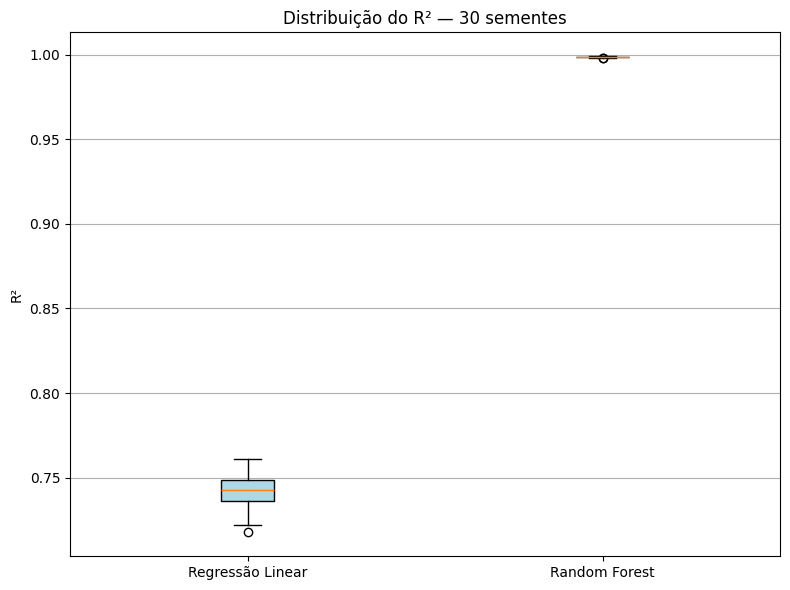

In [36]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [df_lr['r2'].values, df_rf['r2'].values],
    tick_labels=['Regressão Linear', 'Random Forest'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
)
plt.ylabel("R²")
plt.title("Distribuição do R² — 30 sementes")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 6.2. Gráfico — R² médio por modelo

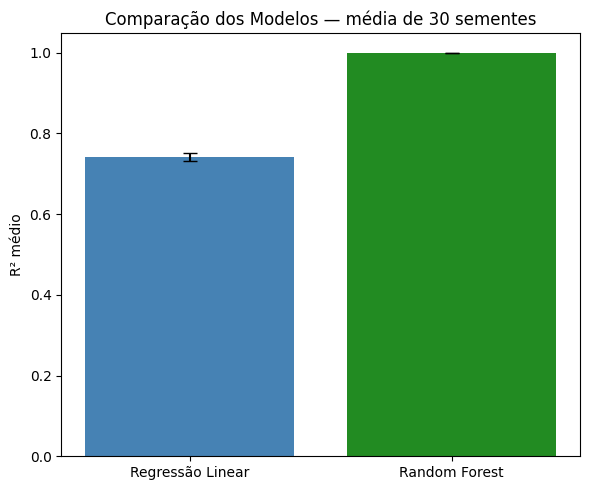

In [37]:
plt.figure(figsize=(6, 5))
plt.bar(
    comparacao['Modelo'],
    comparacao['R² (média)'],
    yerr=comparacao['R² (std)'],
    capsize=5,
    color=['steelblue', 'forestgreen'],
)
plt.ylabel("R² médio")
plt.title("Comparação dos Modelos — média de 30 sementes")
plt.tight_layout()
plt.show()

## 6.3 Gráfico — Real vs Previsto

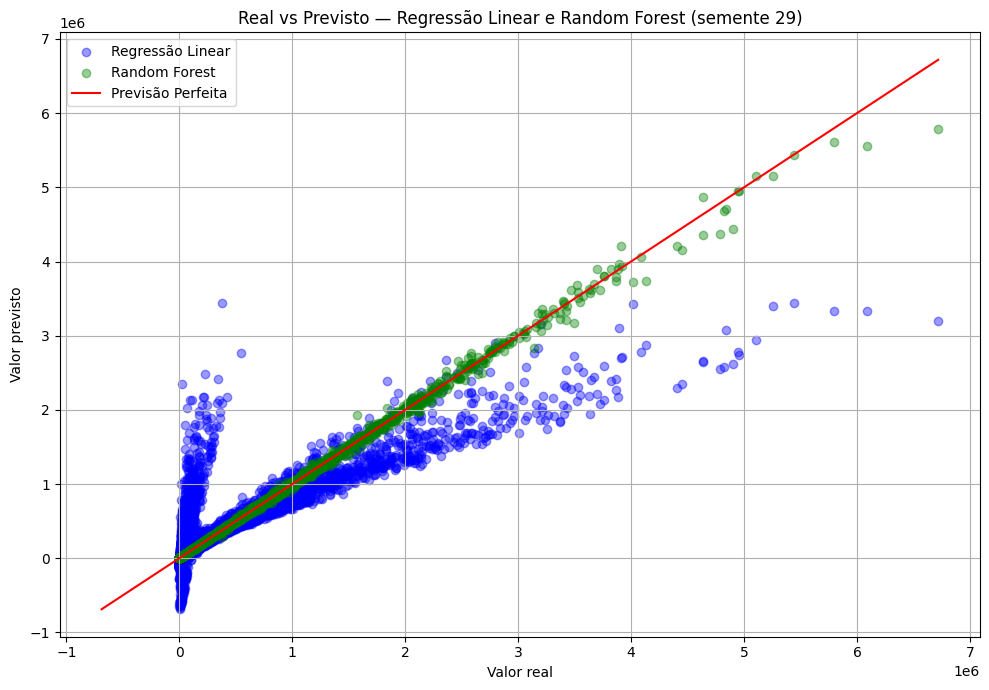

In [42]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(y_val, y_pred_val_lr, alpha=0.4, color='blue', label='Regressão Linear')
ax.scatter(y_val, y_pred_val_rf, alpha=0.4, color='green', label='Random Forest')

min_val = min(y_val.min(), y_pred_val_lr.min(), y_pred_val_rf.min())
max_val = max(y_val.max(), y_pred_val_lr.max(), y_pred_val_rf.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=1.5, label='Previsão Perfeita')

ax.set_xlabel("Valor real")
ax.set_ylabel("Valor previsto")
ax.set_title(f"Real vs Previsto — Regressão Linear e Random Forest (semente {sementes[-1]})")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()